In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
df =  pd.read_csv('credit_risk_dataset.csv')

In [36]:
df.shape

(32581, 12)

In [37]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [38]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [39]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [40]:
df['loan_status'].unique()
df['loan_status'].value_counts() #checking the class imbalance 

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

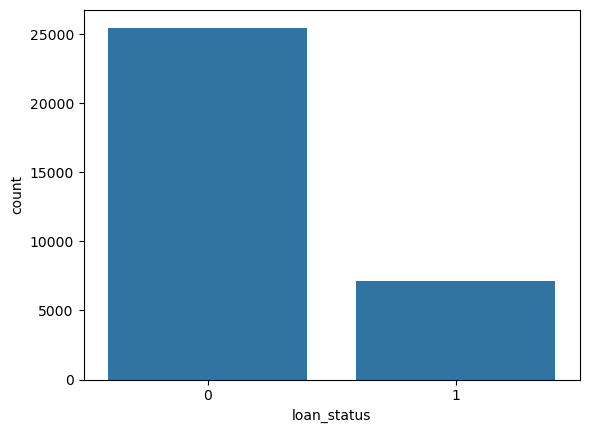

In [41]:
#plotting of class imbalance
sns.countplot(x='loan_status', data=df)

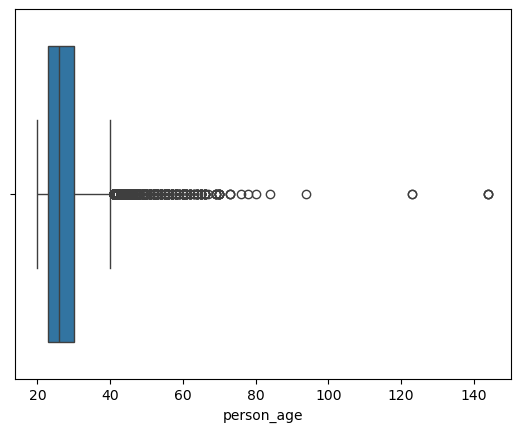

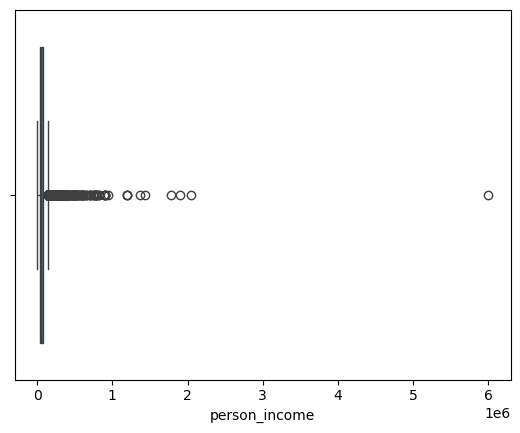

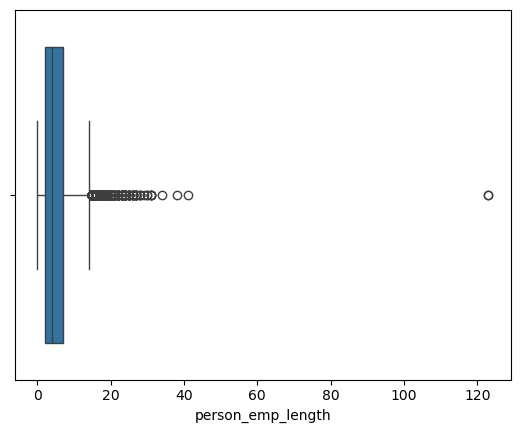

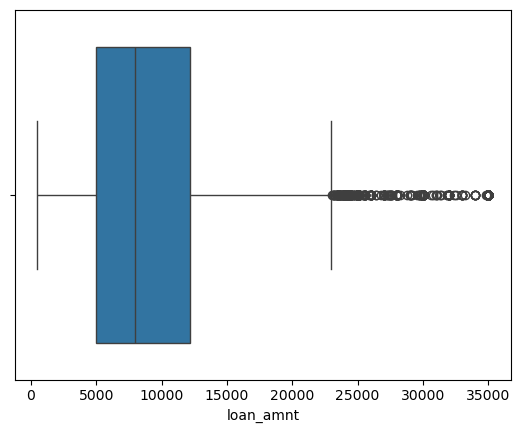

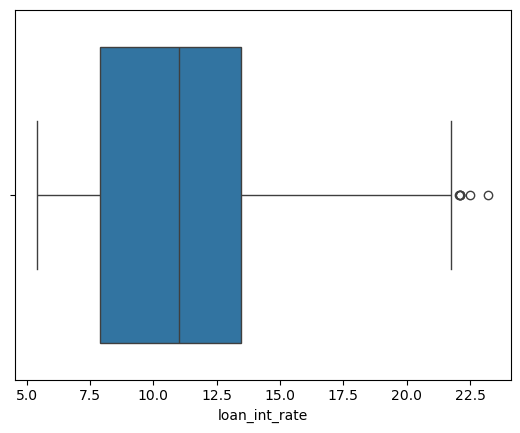

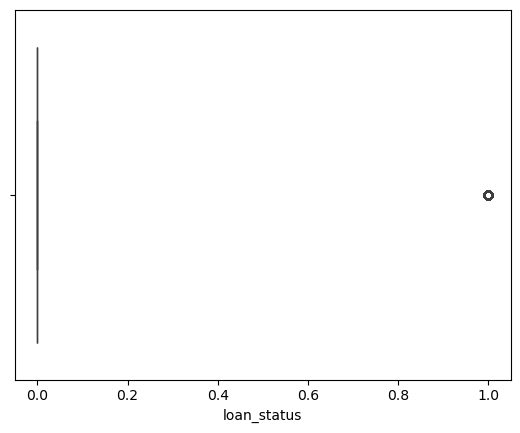

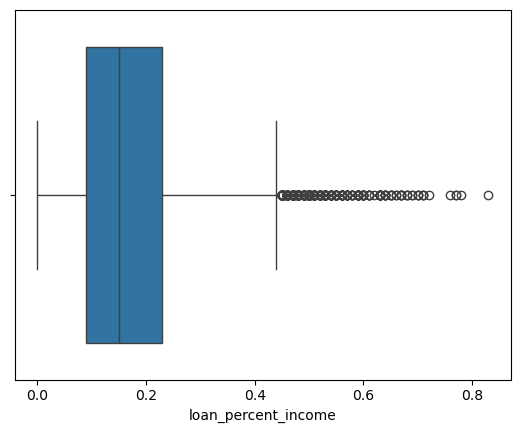

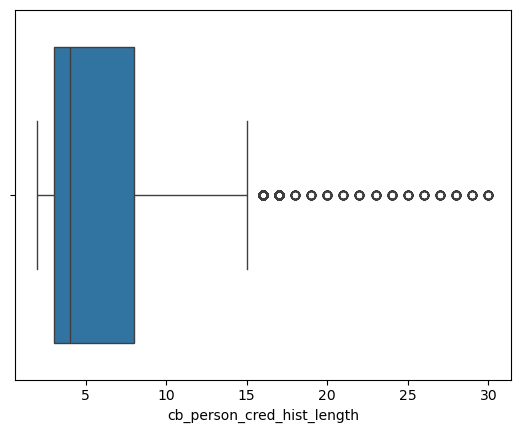

In [42]:
#extracting numerical cols - outlier check 
numerical_cols=df.select_dtypes(include=np.number).columns
for i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()

In [43]:
# have total 5 people that have age more than 100
(df['person_age']>100).sum()

np.int64(5)

In [44]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [45]:
# finding outlier in person emp lenght
(df['person_emp_length']>60).sum()
# total 2 outlier

np.int64(2)

In [46]:
#outlier check
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

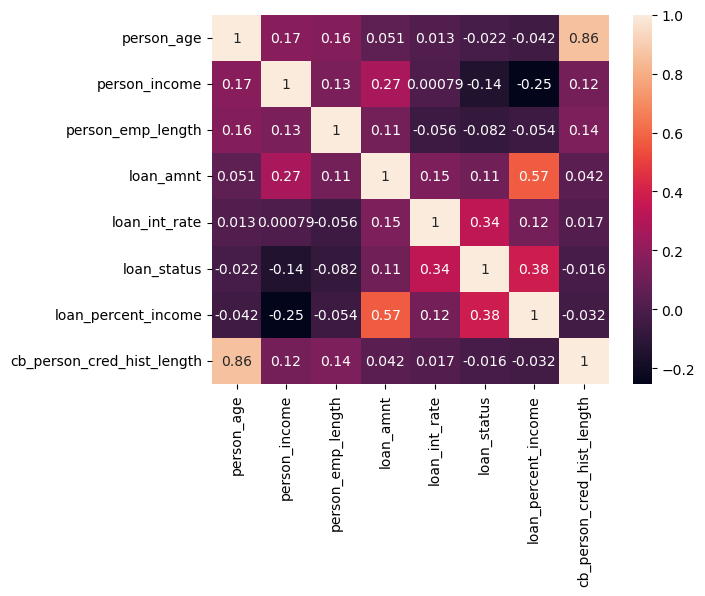

In [47]:
## checking the coralation in features 
sns.heatmap(df.corr(numeric_only=True), annot=True)

# target col = loan status

In [48]:
#data validation and outlier handling

df_copy=df.copy()
print(f"original rows: {df_copy.shape[0]}")

#removing duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"rows after removing suplicates: {df_copy.shape[0]}")


# remove ages below 18 and above 100
df_copy = df_copy[df_copy['person_age']>=18] # to find actual values.
df_copy = df_copy[df_copy['person_age']<=100]

# remove emp length greater than age or extream outlier(>60)
df_copy=df_copy[df_copy['person_emp_length']<= df_copy['person_age']]
df_copy=df_copy[df_copy['person_emp_length']<= 60]


# removing the rows with xero or negative income or loan ammount
df_copy = df_copy[df_copy['loan_amnt']>0]

#check if the interest rate looks realistic
print("loan interest rate range from (min : 5.42 and max:23.22)")

original rows: 32581
rows after removing suplicates: 32416
loan interest rate range from (min : 5.42 and max:23.22)


In [49]:
#to check that is it applied correctly or not
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [50]:
x = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#stratify - to equaily divide in traing and testing data

In [52]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 
                'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_cred_hist_length' ]

In [53]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [54]:
#class weights- to assign the weight to the features  who have less weight
#0 -> no laon(most)
#1 -> yes loan

neg, pos = np.bincount(y_train)
scale_weights = neg/pos  #-> class weight for xg boost algo, as it have no in built function for weight balancing

In [55]:

neg 


np.int64(19772)

In [56]:
pos

np.int64(5445)

In [57]:
#Logistic regression : impute + SCALE Numeric, impute + one-hot-encoding
# we are crearing the 2 pipeline cause there is no inbuilt functio for class weight so for better understandain
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder



preprocessor_lr = ColumnTransformer( #columntransformer used to transfer the data in respective columns
    transformers = [
        #for numerical column
        ('num', Pipeline ([ #for numerical col
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #pipeline for categorical col
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value = "Missing")),
            ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
        ]), categorical_cols)
    ]
)

In [58]:
#XGBoost impute numeric only (no scaling), impute + one hot encoding

preprocessor_xg = ColumnTransformer( #columntransformer used to transfer the data in respective columns
    transformers = [
        #for numerical column
        ('num', Pipeline ([ #for numerical col
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #pipeline for categorical col
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value = "Missing")),
            ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
        ]), categorical_cols)
    ]
)

In [59]:
from sklearn.metrics import accuracy_score, classification_report, precision_score,recall_score, f1_score, confusion_matrix, precision_recall_curve
def evaluate_model(model_name, model, x_test, y_test, threshold=None):
    #y_pred = model.predict(x_test)
    y_pred_prob = model.predict_proba(x_test)[:, 1]

    if threshold:
        y_pred=(y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision_s = precision_score(y_test, y_pred)
    recall_s = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    print(f"{model_name} metrics:")
    print(f"Best Threshold: {best_threshold}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision_s:.2f}")
    print(f"Recall: {recall_s:.2f}")
    print(f"F1: {f1:.2f}")
    print()
    print(f"{model_name} Classification Report")
    print(class_report)

    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual values")
    plt.xlabel("Predicted values")
    plt.show()

    precision, recall, threshold = precision_recall_curve(
        y_test, y_pred_prob
    )

    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()

In [60]:
## stratified 

from sklearn.model_selection import StratifiedKFold

cv=StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [61]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier",LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
lr_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
#XG boost model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weights,
        random_state=42
    ))
])

In [63]:
 # to perform cross validation we neeed 
# 1)model of pipeline, 2)data, 3) cv, 4) scoring
from sklearn.model_selection import cross_validate
for cv_name, pipe in [("logistic regression", lr_cv_pipeline),
                     ("XGBoost", xgb_cv_pipeline)]:
    cv_result=cross_validate(pipe, x_train, y_train, cv=cv, scoring=scoring, n_jobs=-1) #passing estimator- esatimator are nothing but ml for training and testing purpose
    print(cv_name)
    print(f"ROC-AUC: {cv_result['test_roc_auc'].mean()}")
    print(f"Accuracy: {cv_result['test_accuracy'].mean()}")
    print(f"Precision: {cv_result['test_precision'].mean()}")
    print(f"Recall: {cv_result['test_recall'].mean()}")
    print(f"F1: {cv_result['test_f1'].mean()}")
# as it has a 5 folds so thats why average of 5 folds

logistic regression
ROC-AUC: 0.8699987786803789
Accuracy: 0.8105639714160049
Precision: 0.54305823769498
Recall: 0.7768595041322314
F1: 0.6391626423399333
XGBoost
ROC-AUC: 0.9389599295155143
Accuracy: 0.9079586452621647
Precision: 0.7889168979276875
Recall: 0.7851239669421488
F1: 0.7865918180754592


In [64]:
#base line model building of LR after hyper parameter tunnng

baseline_model=Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
#evaluate the Logistic Model.
evaluate_model("Baseline Logistic Model", baseline_model, x_test, y_test)

Baseline Logistic Model metrics:


NameError: name 'best_threshold' is not defined

In [66]:
#as data has 5 folds so thats why 5 roc, auc
cv_result

{'fit_time': array([1.01528668, 0.98908234, 0.73735571, 0.73546624, 0.76180577]),
 'score_time': array([0.17409325, 0.16839194, 0.1919837 , 0.18768191, 0.17314124]),
 'test_roc_auc': array([0.94320065, 0.93010394, 0.94103308, 0.94357088, 0.9368911 ]),
 'test_accuracy': array([0.90999207, 0.91276764, 0.90918104, 0.90898275, 0.89886972]),
 'test_precision': array([0.79589935, 0.82160555, 0.79624413, 0.77975133, 0.75108413]),
 'test_recall': array([0.78420569, 0.76124885, 0.77869605, 0.80624426, 0.79522498]),
 'test_f1': array([0.79000925, 0.79027645, 0.78737233, 0.79277652, 0.77252453])}

In [67]:
#xg hyperparamater tunning
xg_model=Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
                                scale_pos_weight=scale_weights, random_state=42))
])
xg_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
#hyper parameter tunning- creation of complete paramater grid
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint # for getting the distribution 
param_grid={
    "classifier__n_estimators": randint(150, 600), # decision tree
    "classifier__max_depth" : randint(3,9), #depth of tree
    "classifier__learning_rate" :uniform(0.01,0.5), #selection of rows randomly 
    "classifier__subsample" :uniform(0.6,0.4), #rows sampling
    "classifier__colsample_bytree" : uniform(0.6,0.4),#column sampling
    "classifier__min_child_weight": randint(1,10), # after splliting the tree the weight assigned for taking the decision that how much it will contribute in decision making
    "classifier__gamma": uniform(0,5) # control the split # lower gama more split- complex tree, high gama- less spplit, low risk of ovwe fitting
    
}

In [69]:
random_search=RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....0022FFCA64410>, 'classifier__gamma': <scipy.stats....0022FF9A12FD0>, 'classifier__learning_rate': <scipy.stats....0022FF8484D70>, 'classifier__max_depth': <scipy.stats....0022FFB4F2710>, ...}"
,n_iter,150
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [70]:
print(f"score after performing tunnig {random_search.best_score_:.2f}")

score after performing tunnig 0.90


In [71]:
#comparing both model side by side 
evaluate_model("Logistic Rgression", baseline_model, x_test, y_test)

Logistic Rgression metrics:


NameError: name 'best_threshold' is not defined

In [72]:
#Passing the XGBoost model after performing Hyperparameter Tuning+
evaluate_model("XGBoost", random_search, x_test, y_test)

XGBoost metrics:


NameError: name 'best_threshold' is not defined

C:\Users\omavi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\omavi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\omavi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\omavi\anaconda3\Lib\site-pa

XGBoost metrics:
Best Threshold: 0.9995341300964355
Accuracy: 0.78
Precision: 0.00
Recall: 0.00
F1: 0.00

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



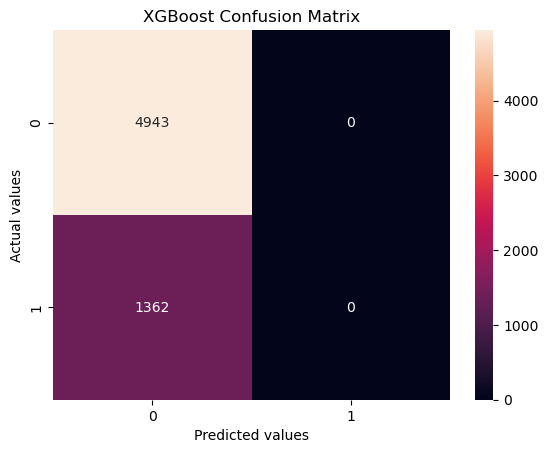

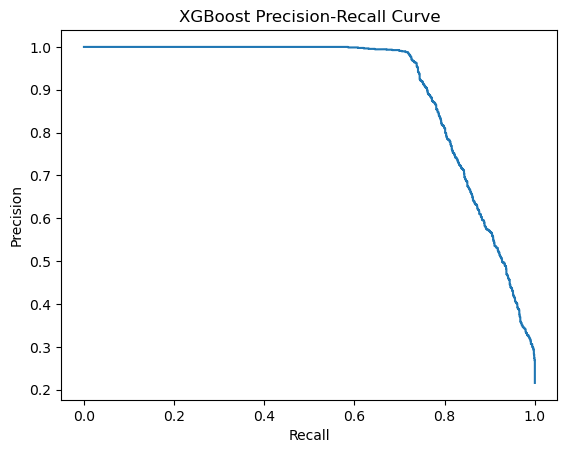

In [73]:
#optimizing threashold

#get the probab of class 1 from xg boost.
prob=xg_model.predict_proba(x_test)[:,1] #[:,1] is for complete 1
prob

# for each threashold calculate precision and recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)
thresholds

#calculate f1 score for each threashold
f1 = 2 * (precisions-recalls) / (precisions + recalls +1e-9)
f1
#get the threashold that produces that highest f1 score
best = np.argmax(f1[:-1])
best #best and highest f1 score value is (6277)
best_threshold = thresholds[best] # to find the value of best threashold where the best f1 gets

#evaluate the xgboost using that threshold
evaluate_model("XGBoost", xg_model, x_test, y_test, best_threshold)



In [74]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.9933965384019141),
 'classifier__gamma': np.float64(0.8484819420793954),
 'classifier__learning_rate': np.float64(0.12376806026120145),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 554,
 'classifier__subsample': np.float64(0.9374197074656323)}

In [75]:
#1 calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model=CalibratedClassifierCV(
    xg_model,
    method="sigmoid",
    cv=cv,
)

calibrated_model.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [76]:
#2 get probabilities
uncalibrated=xg_model.predict_proba(x_test)[:,1]
calibrated=calibrated_model.predict_proba(x_test)[:,-1]

In [77]:
calibrated

array([0.75814259, 0.05576104, 0.95066211, ..., 0.17095293, 0.01851418,
       0.01476903], shape=(6305,))

In [78]:
uncalibrated

array([0.8318908 , 0.21366374, 0.97647846, ..., 0.52364564, 0.07239438,
       0.04686361], shape=(6305,), dtype=float32)

In [79]:
#3 create clabiration curve
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [80]:
#4 create clabiration curve
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

<module 'matplotlib.pyplot' from 'C:\\Users\\omavi\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

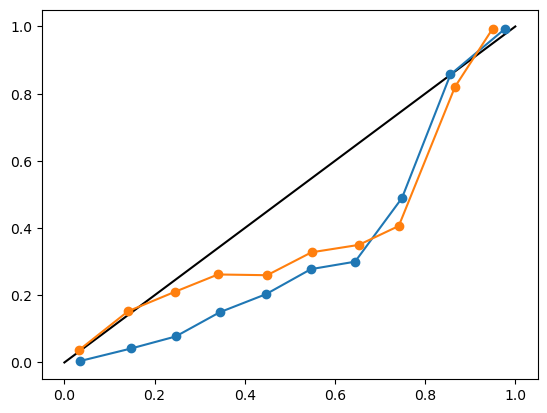

In [81]:
#4 plot
plt.plot([0,1], [0,1], '-k', label="Perfect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "calibrated"
)

plt

In [82]:
#shap 
import shap
#1- get the trained XGBoost classifier out of the pipeline.
xgb_classifier=xg_model.named_steps['classifier']
xgb_classifier

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [83]:
#2- transform x_test using the same perprocessing used fot training.
x_test_transformed=xg_model.named_steps['preprocessor'].transform(x_test)

In [84]:
#3- get feature name after one hot encoding, so plots are readable
feature_names=xg_model.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
# 4 - Convert transformed test data to DataFrame for SHAP plots

# Get the preprocessor from the pipeline
preprocessor = xg_model.named_steps['preprocessor']

# Transform test data
x_test_transformed = preprocessor.transform(x_test)

# Convert sparse matrix to normal NumPy array
x_test_transformed = x_test_transformed.toarray()

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Check shapes
print("Transformed shape:", x_test_transformed.shape)
print("Feature names:", len(feature_names))

# Convert to DataFrame
x_test_df = pd.DataFrame(
    x_test_transformed,
    columns=feature_names
)

x_test_df

In [ ]:
#5- create SHAP explainer built for tree base model.
explainer=shap.TreeExplainer(xgb_classifier)

In [ ]:
#6- calculate shap value for every row in test set
shap_values=explainer.shap_values(x_test_df)
shap_values

In [ ]:
#global explanation
shap.summary_plot(shap_values, x_test_df)

In [ ]:
#local explanation
#1- pick one row to explain e.g. the 5th applicant in the test set.
row_index = 5


#2- draw waterfall plot showing how each features pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data= x_test_df.iloc[row_index],
        feature_names=feature_names
        
    )
)

# analyzing false positive and false negative.
Analyzing False Positives & False Negatives
The model will not be perfect.
False positives are safe people wrongly marked risky.
False negatives are risky people wrongly marked safe.
We study these cases to understand where the model struggles.

In [ ]:
#get predictions from best performing  XHBoost model on the test set.

y_pred=random_search.predict(x_test)

In [ ]:
#create dataframe to easiliy compare the actual predicted values
result_df = x_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [ ]:
result_df

In [ ]:
#identify  false positive : model predicted 1, but the actual was 0.
false_positive=result_df[(result_df['actual']==0)  & (result_df['predicted']==1)]

In [ ]:
# identify false negative : model predicted 0, but the actual was 1.
false_negative=result_df[(result_df['actual']== 1) & (result_df['predicted']==0)]

In [ ]:
print(f"false positive : {len(false_positive)}")
print(f"false negative : {len(false_negative)}")

In [ ]:
#false negative > false positive

In [ ]:
#going to use xg  hyper parameter tuned mmdel 

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

#1 get probabilities from the calibrated model, not the old xg_model
calibrated_proba = calibrated_model.predict_proba(x_test)[:,1]

#2 re-run the same threashold search, now the correct probability scale
precisions, recall, threasholds= precision_recall_curve(y_test, calibrated_proba)
f1_score =  2*(precisions * recall) / (precisions + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_score[:-1])]

print("new threshold:", best_threshold)

In [ ]:
#exporting the model - tha is calibrated 
import joblib


joblib.dump(calibrated_model, "credit_risk_model.pkl")

In [ ]:
joblib.dump(best_threshold, "best_threshold.pkl")